In [23]:
import sys
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData
from src.data_processing.patchify import Patchify
from src.data_processing.patch_reconstructor import PatchReconstructor

## Load data

CoastData: global - 1717 images
Coast: agrelo, Total size: 244
Coast: arenaldentem, Total size: 40
Coast: cadiz, Total size: 946
Coast: cies, Total size: 430
Coast: samarador, Total size: 57
Path: /LOCALDATA/josep/Shoreline-extraction/data/processed_obliques_2_classes/images/1555342200.Mon.Apr.15_16_30_00.CET.2019.agrelo.image.jpg


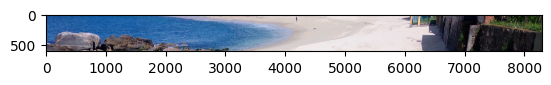

[0 1]


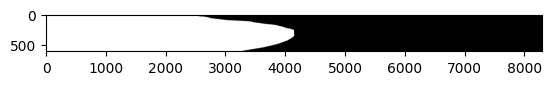

In [24]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_obliques_2_classes/"))

# Load the data, all the different stations
data = CoastData(data_path, name="global") # arenaldentem

filtered_data = data.get_images_and_masks() 

filtered_data = data.split_data()

# Get the first image and mask
image = filtered_data['train']['images'][0]
mask = filtered_data['train']['masks'][0]

print("Path:", image)

img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()
mask_img = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)
print(np.unique(mask_img))
plt.imshow(mask_img, cmap='gray')

In [25]:
patchify = Patchify(patch_size=(256, 1024), stride=(128, 512))

result = patchify.extract_patches(image, mask, skip_background=False, skip_no_shoreline=True, binary_class=True, p_keep_negative=1, padding_mode='reflect')
patches = result['patches']

In [26]:
print("Number of patches:", len(patches))

Number of patches: 85


Rows: 4


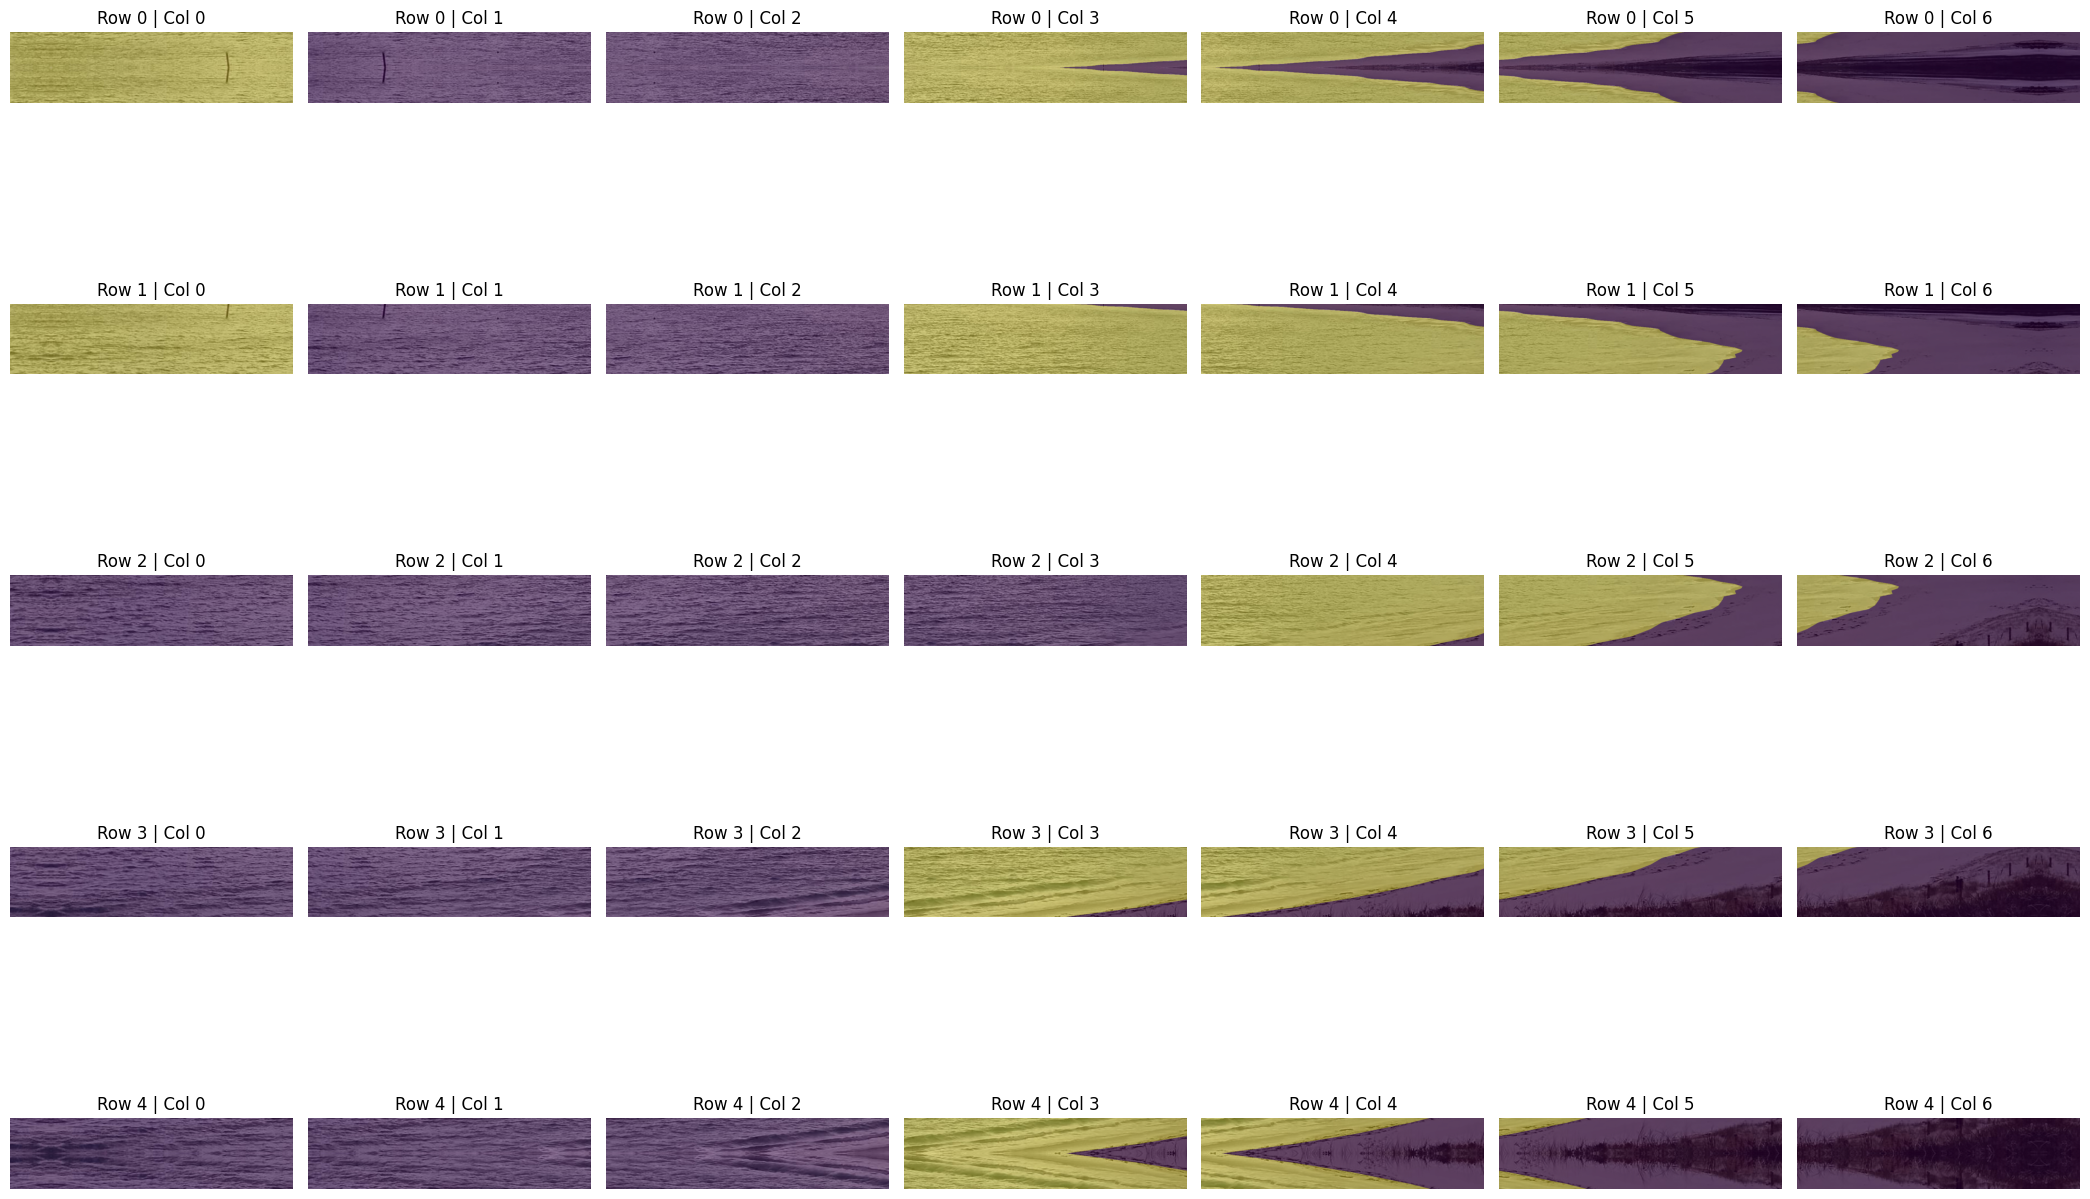

In [17]:
rows = max(patch['row'] for patch in patches)
cols = max(patch['col'] for patch in patches)
print("Rows:", rows)

# Create subplots
fig, axes = plt.subplots(rows + 1, cols + 1, figsize=(3*(cols + 1), 3 * (rows + 1)))
axes = axes.flatten()

# Show each patch
for i, patch in enumerate(patches):
    ax = axes[patch['row'] * (cols + 1) + patch['col']]
    patch['image'] = cv2.cvtColor(patch['image'], cv2.COLOR_BGR2RGB)
    ax.imshow(patch['image'])
    ax.imshow(patch['mask'], alpha=0.4)
    ax.set_title(f"Row {patch['row']} | Col {patch['col']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
extract_patches_and_save = patchify.extract_patches_and_save(filtered_data, output_dir='../../../data/patchify_2_classes_oblique_256x1024/', skip_no_shoreline=True, binary_class=True, p_keep_negative=1, padding_mode='reflect')

Extracting patches for train dataset...
Finished extracting patches for train dataset.

Extracting patches for validation dataset...
Finished extracting patches for validation dataset.

Extracting patches for test dataset...
Finished extracting patches for test dataset.

